In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Used Car Dataset.csv")

##### Data Describe untuk menampilkan rata-rata, standar deviasi, nilai minimum, nilai maksimum, Q1, Q2, dan Q3 dari attribute bertipe angka.

In [5]:
df.describe()

,Unnamed: 0,seats,kms_driven,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
count,1553.000000,1553.000000,1553.000000,1550.000000,1.550000e+03,1.550000e+03,1.549000e+03,1553.000000
mean,776.000000,91.480361,52841.931101,236.927277,1.471857e+10,1.471857e+10,1.423989e+04,166.141494
std,448.456798,2403.424060,40067.800347,585.964295,2.185629e+11,2.185629e+11,9.666241e+04,3478.855090
min,0.000000,4.000000,620.000000,7.810000,5.000000e+00,5.000000e+00,5.000000e+00,1.000000
25%,388.000000,5.000000,30000.000000,16.342500,1.197000e+03,1.197000e+03,4.000000e+02,4.660000
50%,776.000000,5.000000,49134.000000,18.900000,1.462000e+03,1.462000e+03,1.173000e+03,7.140000
75%,1164.000000,5.000000,70000.000000,22.000000,1.995000e+03,1.995000e+03,8.850000e+03,17.000000
max,1552.000000,67000.000000,810000.000000,3996.000000,3.258640e+12,3.258640e+12,1.464800e+06,95000.000000


In [14]:
print("10 record teratas")
df.select_dtypes(include="number").head(10)

10 record teratas


,Unnamed: 0,seats,kms_driven,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,0,5,56000,7.81,2996.0,2996.0,333.0,63.75
1,1,5,30615,17.40,999.0,999.0,9863.0,8.99
2,2,5,24000,20.68,1995.0,1995.0,188.0,23.75
3,3,5,18378,16.50,1353.0,1353.0,13808.0,13.56
4,4,5,44900,14.67,1798.0,1798.0,17746.0,24.00
5,5,5,42000,18.70,1199.0,1199.0,887.0,5.45
6,6,5,36739,18.90,1197.0,1197.0,8186.0,5.12
7,7,5,76000,15.80,1591.0,1591.0,1213.0,9.30
8,8,5,68000,13.50,2987.0,2987.0,25479.0,42.00
9,9,5,28783,17.00,1198.0,1198.0,1085.0,8.02


##### Shape untuk menampilakan informasi baris [0] dan kolom [1]; tolist untuk menampilkan nama kolom

In [12]:
print("=== Informasi Dataset ===")
print(f"Jumlah record           : {df.shape[0]}")
print(f"Jumlah attribute        : {df.shape[1]}")
print(f"Nama attribute          : {df.columns.tolist()}")
print(f"Jumlah Attribute bertipe angka: {df.select_dtypes(include='number').shape[1]}")

=== Informasi Dataset ===
Jumlah record           : 1553
Jumlah attribute        : 15
Nama attribute          : ['Unnamed: 0', 'car_name', 'registration_year', 'insurance_validity', 'fuel_type', 'seats', 'kms_driven', 'ownsership', 'transmission', 'manufacturing_year', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)', 'price(in lakhs)']
Jumlah Attribute bertipe angka: 8


In [10]:
print(f"Jumlah Atribute bertipe object: {df.select_dtypes(include='object').shape[1]}")

Jumlah Atribute bertipe object: 7


VISUALISASI PERTAMA


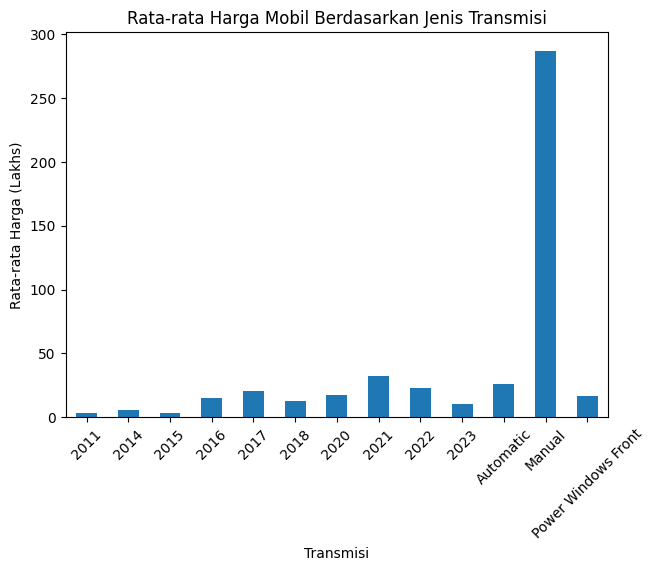

In [25]:
print("VISUALISASI PERTAMA")
rata_harga = df.groupby('transmission')['price(in lakhs)'].mean()

plt.figure(figsize=(7, 5))
rata_harga.plot(kind='bar')

plt.title('Rata-rata Harga Mobil Berdasarkan Jenis Transmisi')
plt.xlabel('Transmisi')
plt.ylabel('Rata-rata Harga (Lakhs)')

plt.xticks(rotation=45)

plt.show()

VISUALISASI KEDUA


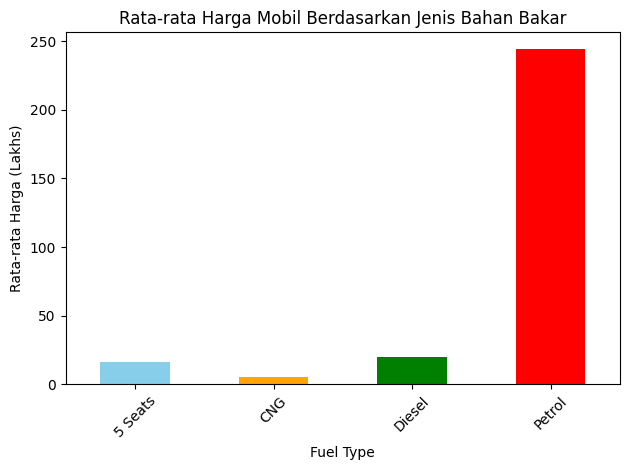

In [37]:
print("VISUALISASI KEDUA")

rata_harga = df.groupby('fuel_type')['price(in lakhs)'].mean()

rata_harga.plot(
    kind='bar',
    color=['skyblue', 'orange', 'green', 'red', 'purple']
)

plt.xlabel('Fuel Type')
plt.ylabel('Rata-rata Harga (Lakhs)')
plt.title('Rata-rata Harga Mobil Berdasarkan Jenis Bahan Bakar')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

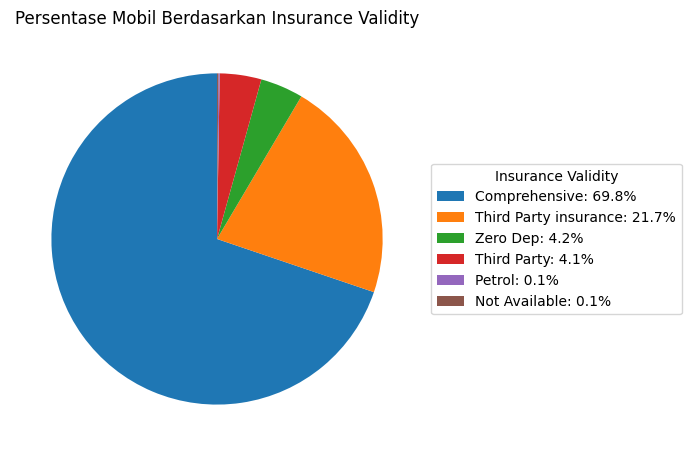

In [36]:
jumlah = df['insurance_validity'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    jumlah,
    labels=None,
    startangle=90
)

# Membuat legend dengan persentase
persentase = jumlah / jumlah.sum() * 100
legend_labels = [
    f'{label}: {persen:.1f}%'
    for label, persen in zip(jumlah.index, persentase)
]

plt.legend(
    legend_labels,
    title='Insurance Validity',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.title('Persentase Mobil Berdasarkan Insurance Validity')
plt.tight_layout()
plt.show()

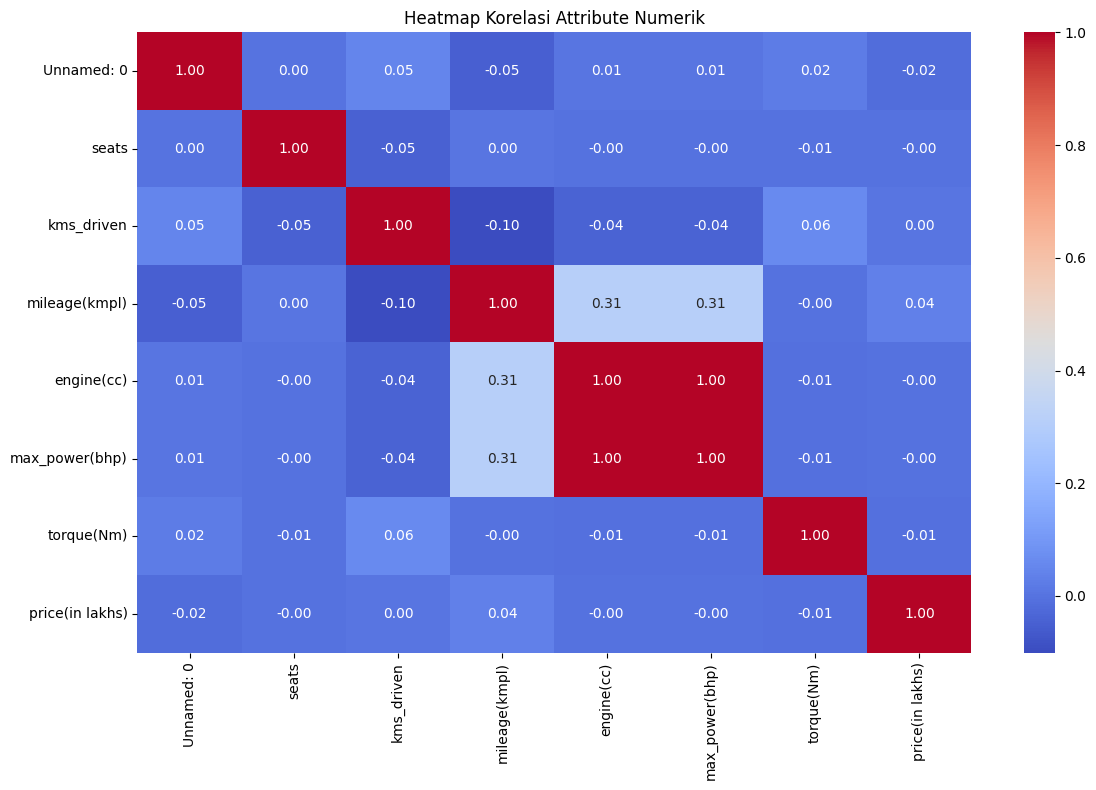

In [27]:
df_numeric = df.select_dtypes(include='number')

korelasi = df_numeric.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    korelasi,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Attribute Numerik')
plt.tight_layout()
plt.show()